<a href="https://colab.research.google.com/github/jpauloluzsf/luzPy/blob/main/Data_Modelling/modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **MODELAGEM DE DADOS GEOELÉTRICOS - CAMINHAMENTO ELÉTRICO**
---

> Esta rotina requer recursos computacionais mínimos e pode ser executado rapidamente em segundo plano enquanto outros processos do computador estão em execução.

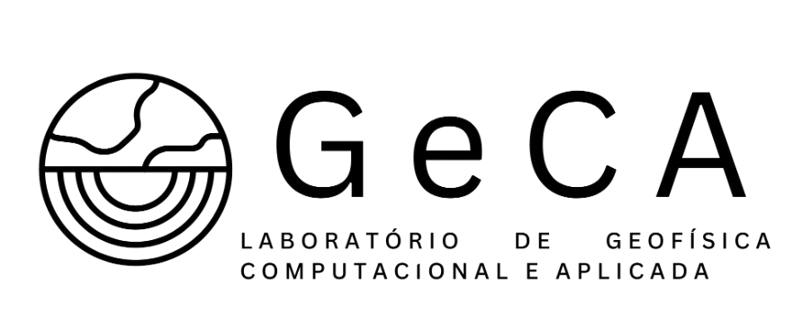

>O módulo/programa a seguir, assim como todos os demais desenvolvidos nesta biblioteca, apresenta-se como uma alternativa confiável e open-source para o processamento e análise de dados eletrorresistivos, oferecendo baixo custo computacional e eliminando a necessidade de softwares pagos. Toda a estrutura foi pensada para garantir transparência e reprodutibilidade, mantendo consistência metodológica entre os diferentes modelos e ferramentas disponibilizados.

</br>

Essa rotina baseia-se na biblioteca **SimPEG – Simulation and Parameter Estimation in Geophysics**, neste trabalho utilizamos o módulo [simpeg.electromagnetics.static.resistivity](xref:simpeg#simpeg.electromagnetics.static.resistivity).

O programa tem como finalidade realizar a modelagem de dados de eletrorresistividade. A ferramenta possibilita a criação e organização desses modelos para que possam ser posteriormente processados e/ou invertidos em outros módulos específicos da própria biblioteca — ou ainda exportados para softwares comerciais amplamente utilizados, como **Res2DInv®** ou **ZondRes2D©**.

</br>

**Objetivos:**

- Como definir linhas de resistividade DC;
- Como projetar uma malha 2D do tipo *tree mesh* (*grid*);
- Como definir as propriedades elétricas da Terra em termos de condutividade ou resistividade;
- Como incluir a topografia da superfície na simulação direta (*forward simulation*);
- Como plotar dados simulados em pseudoseção.

</br>  

> Esta rotina e o material foram desenvolvidos por **João Paulo Luz Ferreira**, como aluno do **Laboratório de Geofísica Computacional e Aplicada (GeCA)**, sob orientação da professora **Flora F. Solon**.  

> A rotina foi criada para uso interno da Empresa Júnior de Geofísica da UFF – **Horizonte Soluções Geofísicas Jr.** e para estudantes em Geociências interessados em aprender e aplicar na prática conceitos teóricos de eletrorresistividade com o auxílio da biblioteca SimPEG.

In [ ]:
pip install -qq simpeg==0.24.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 508.0/508.0 kB 8.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.7/211.7 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.5/172.5 kB 12.6 MB/s eta 0:00:00



## Importando Módulos

Aqui, importamos toda a funcionalidade necessária para executar o programa. Toda a funcionalidade específica para 'Dc Resistivity' é importada do módulo [simpeg.electromagnetics.static.resistivity](xref:simpeg#simpeg.electromagnetics.static.resistivity). Também importamos algumas funções utilitárias úteis do módulo [simpeg.utils](xref:simpeg#simpeg.utils).  


In [ ]:
# SimPEG functionality
from simpeg.electromagnetics.static import resistivity as dc
from simpeg.utils import model_builder
from simpeg.utils.io_utils.io_utils_electromagnetics import write_dcip2d_ubc
from simpeg import maps, data
from simpeg.electromagnetics.static.utils.static_utils import (generate_dcip_sources_line,pseudo_locations,plot_pseudosection,apparent_resistivity_from_voltage,)
# discretize functionality
from discretize import TreeMesh
from discretize.utils import active_from_xyz
# Common Python functionality
import os
import numpy as np
from scipy.interpolate import interp1d
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
mpl.rcParams.update({"font.size": 14})  # default font size
#Tirando os avisos de d_pred
import warnings
from simpeg.utils.solver_utils import DefaultSolverWarning
from scipy.sparse import SparseEfficiencyWarning
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=DefaultSolverWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=SparseEfficiencyWarning)

## Definindo Parâmetros


In [ ]:
#Gerar arquivo de saída?
writeOutput = False

#Topografia plana?
flatTopography = False

####################################### PARÂMETROS DA LINHA ########################################

lineLength = 800
eSpace = 40
invLevel =  10

In [ ]:
## Parâmetros básicos (recomenda-se não mexer)
end_locations = np.r_[-(lineLength/2), (lineLength/2)]
survey_type = "dipole-dipole"
dimension_type = "2D"
data_type = "volt"
lineLength = int(end_locations[-1] - end_locations[0])
lineLength_base = 800
topoLength_base = 4000
topoLength = lineLength * (topoLength_base / lineLength_base)

## Definindo a Topografia

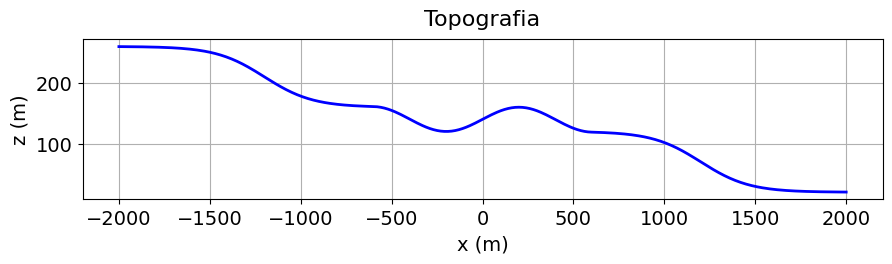

In [ ]:
if flatTopography:
    x_topo = np.linspace(-topoLength/2, topoLength/2, 401)
    #x_topo = np.linspace(-750, 750, 401)
    # Define flat elevation
    z_topo = np.full_like(x_topo, 680)
    topo_2d = np.c_[x_topo, z_topo]
else:
  x_topo = np.linspace(-2000, 2000, 401)
  T = 800.0
  z_topo = 20.0 * np.sin(2 * np.pi * x_topo / T) + 140.0
  z_topo[x_topo < -3 * T / 4] = 160.0
  z_topo[x_topo > 3 * T / 4] = 120.0
  z_topo += 50.0 * (1.0 + np.tanh(-3 * (x_topo + 1200.0) / T))
  z_topo -= 50.0 * (1.0 + np.tanh(3 * (x_topo - 1200.0) / T))
  topo_2d = np.c_[x_topo, z_topo]

# Plot
fig = plt.figure(figsize=(10, 2))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.plot(x_topo, z_topo, color="b", linewidth=2)
ax.set_xlabel("x (m)", labelpad=5)
ax.set_ylabel("z (m)", labelpad=5)
ax.grid(True)
ax.set_title("Topografia", fontsize=16, pad=10)
plt.show(fig)

## Definindo o Levantamento (Survey)

Levantamentos de DC (e IP) dentro do SimPEG requerem que o usuário crie e conecte três tipos de objetos:

- [receivers](xref:simpeg#simpeg.electromagnetics.static.resistivity.receivers.BaseRx): define a localização dos eletrodos de potencial (ou MN) e o tipo de dado; por exemplo, 'volt' para tensão normalizada (V/A), 'apparent_resistivity' para resistividade aparente ($\Omega m$) ou 'apparent_chargeability' para carga aparente (adimensional). *Observação: apenas as localizações dos eletrodos M são necessárias para definir receptores tipo pólo*.  
- [sources](xref:simpeg#simpeg.electromagnetics.static.resistivity.sources.BaseSrc): define a localização dos eletrodos de corrente (ou AB) e seus receptores associados. *Observação: apenas as localizações dos eletrodos A são necessárias para definir fontes tipo pólo*.  
- [survey](xref:simpeg#simpeg.electromagnetics.static.resistivity.Survey): objeto que armazena e organiza todas as fontes e receptores.

Número de pontos totais : 135


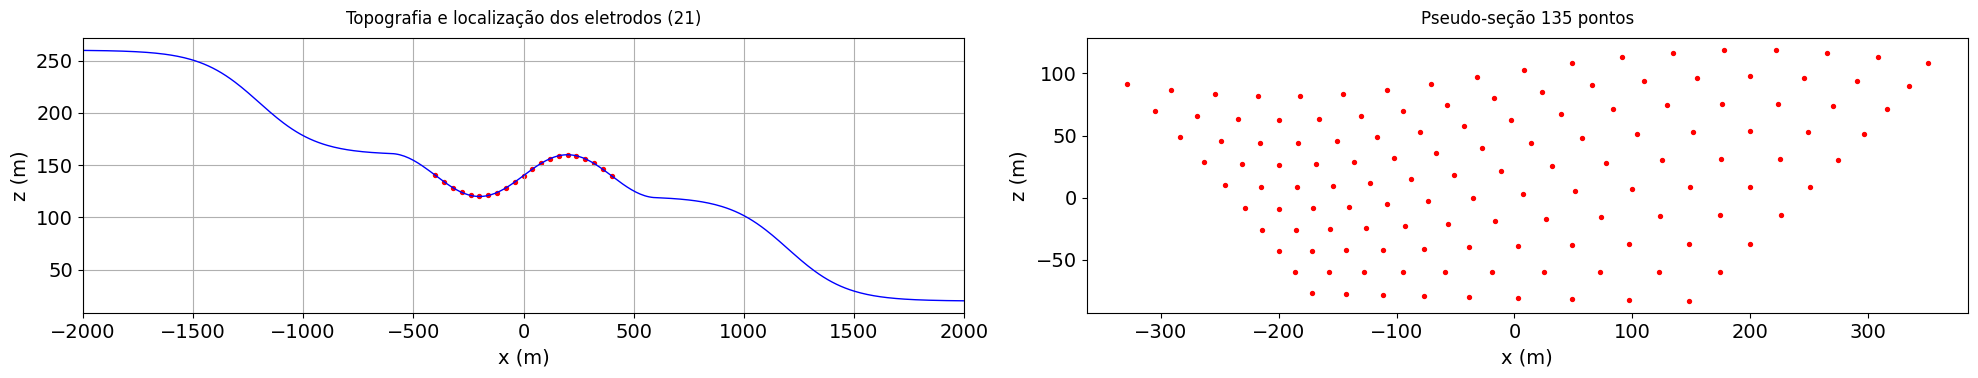

In [ ]:
interp_fun = interp1d(x_topo, z_topo)
electrode_locations_x = np.arange(end_locations[0], end_locations[1] + eSpace, eSpace)
electrode_locations_z = interp_fun(electrode_locations_x)
electrode_locations = np.c_[electrode_locations_x, electrode_locations_z]
n_electrodes = len(electrode_locations_x)
source_list = []
ii = 0
while ii < n_electrodes - 3:
    # Posição dos eletrodos A e B
    location_a = electrode_locations[ii, :]
    location_b = electrode_locations[ii + 1, :]
    # Posição dos eletrodos M e N
    ii_max = np.min([ii + 3 + invLevel, n_electrodes])
    locations_m = electrode_locations[ii + 2 : ii_max - 1]
    locations_n = electrode_locations[ii + 3 : ii_max]
    receivers_list = [dc.receivers.Dipole(locations_m=locations_m, locations_n=locations_n, data_type=data_type)]
    source_list.append(dc.sources.Dipole(receivers_list, location_a=location_a, location_b=location_b))
    ii += 1
survey = dc.Survey(source_list)

others = sum(range(1, invLevel))
nPoints = ((int(lineLength / eSpace + 1)) - (invLevel + 2)) * invLevel + others
print(f'Número de pontos totais : {nPoints}')

fig, axs = plt.subplots(1, 2, figsize=(20, 4))

# Subplot 1
axs[0].plot(x_topo, z_topo, color="b", linewidth=1)
axs[0].scatter(electrode_locations_x, electrode_locations_z, 8, "r")
axs[0].set_xlim([x_topo.min(), x_topo.max()])
axs[0].set_xlabel("x (m)", labelpad=5)
axs[0].set_ylabel("z (m)", labelpad=5)
axs[0].grid(True)
axs[0].set_title(f"Topografia e localização dos eletrodos ({int(n_electrodes)})", fontsize=12, pad=10)

# Subplot 2
pseudo_locations_xz = pseudo_locations(survey)
axs[1].scatter(pseudo_locations_xz[:, 0], pseudo_locations_xz[:, -1], 8, "r")
axs[1].set_xlabel("x (m)", labelpad=5)
axs[1].set_ylabel("z (m)", labelpad=5)
axs[1].set_title(f"Pseudo-seção {int(nPoints)} pontos", fontsize=12, pad=10)
plt.tight_layout()
plt.show()

## Design de uma Malha (Tree Mesh)

As malhas são projetadas usando o pacote [discretize](https://discretize.simpeg.xyz/en/main). Veja os [tutoriais do usuário do discretize](https://discretize.simpeg.xyz/en/main/tutorials/mesh_generation/index.html) para aprender mais sobre a criação de malhas.

**Abordagem padrão para DC:** O potencial elétrico produzido por um eletrodo de corrente decai como $r^{-3}$. Portanto, células menores são necessárias próximas aos eletrodos de corrente para modelar os campos com precisão, e células maiores podem ser usadas longe dos eletrodos de corrente, onde os campos são mais suaves. Para a malha de resistividade DC, recomendamos as seguintes considerações e regras práticas:

1. Como não há correntes no ar, não precisamos adicionar padding para cima. Ou seja, o topo da malha corresponde ao topo da topografia.
2. Precisamos de pelo menos 2-3 células entre cada eletrodo de corrente; resultados mais precisos são obtidos quando o tamanho mínimo da célula é menor. Para uma geometria de problema 2.5D, podemos discretizar muito mais finamente.
3. Para garantir segurança, a espessura do padding deve ser pelo menos 2-3 vezes o maior espaçamento entre eletrodos.
4. O aumento do tamanho das células à medida que se afastam dos eletrodos de corrente não deve acontecer de forma muito abrupta. Em cada tamanho de célula, deve haver uma camada com pelo menos 4 células de espessura antes de aumentar o tamanho da célula.
5. Uma discretização mais fina é necessária quando a topografia é significativa.

**Malha do tutorial:** Aqui, uma largura mínima de célula de 1/10 do menor espaçamento entre eletrodos é usada dentro da região do levantamento. Usando o método [refine_surface](xref:discretize#discretize.TreeMesh.refine_surface), refinamos a tree mesh onde há topografia significativa. E usando o método [refine_points](xref:discretize#discretize.TreeMesh.refine_points), refinamos com base nas localizações dos eletrodos. Visite a API da [tree mesh](xref:discretize#discretize.TreeMesh) para ver métodos adicionais de refinamento.

# de células: 12254
# de faces em x: 12178
Origem: [-2048.         -1788.24726232]
Tamanho da maior célula: 262144.0


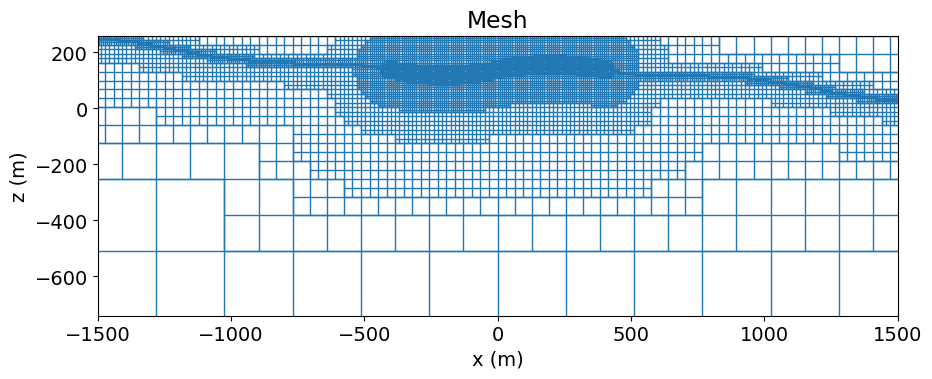

In [ ]:
'''
dh = topoLength / 1000  # base cell width
dom_width_x = topoLength - lineLength  # domain width x
dom_width_z = topoLength - (2 * lineLength)   # domain width z
'''

dh = eSpace/10
dom_width_x = 3200.0
dom_width_z = 2400.0
nbcx = 2 ** int(np.round(np.log(dom_width_x / dh) / np.log(2.0)))  # número de células base em x
nbcz = 2 ** int(np.round(np.log(dom_width_z / dh) / np.log(2.0)))  # número de células base em z
# Define a malha base com o topo em z = 0 m.
hx = [(dh, nbcx)]
hz = [(dh, nbcz)]

############################################### MESH ###############################################

mesh = TreeMesh([hx, hz], x0="CN", diagonal_balance=True)
# Desloca o topo para a elevação máxima da topografia
mesh.origin = mesh.origin + np.r_[0.0, z_topo.max()]
# Refinamento da malha com base na topografia
mesh.refine_surface(topo_2d, padding_cells_by_level=[0, 0, 4, 4], finalize=False,)
# Extrai localizações dos eletrodos
unique_locations = survey.unique_electrode_locations
# Refinamento da malha próximo aos eletrodos
mesh.refine_points(unique_locations, padding_cells_by_level=[8, 12, 6, 6], finalize=False)
mesh.finalize()


#Podemos extrair algumas propriedades da malha
print("# de células: {}".format(mesh.n_cells))  #N° de células
print("# de faces em x: {}".format(mesh.n_faces_x))  #N° de faces na direção x
print("Origem: {}".format(mesh.origin))
print("Tamanho da maior célula: {}".format(mesh.cell_volumes.max()))  #Maior tamanho de célula
#print(mesh.cell_centers[0:5, :])  #Localizações do centro das células


# Índices das células ativas da malha a partir da topografia (células abaixo da superfície)
#As células de ar são comumente chamadas de 'células inativas' (inactive cells)
active_cells = active_from_xyz(mesh, topo_2d)
# Número de células ativas
n_active = np.sum(active_cells)


# Plot
fig = plt.figure(figsize=(10, 4))
ax1 = fig.add_axes([0.14, 0.17, 0.8, 0.7])
mesh.plot_grid(ax=ax1, linewidth=1)
ax1.grid(False)
ax1.set_xlim(-1500.0, 1500.0)
ax1.set_ylim(np.max(z_topo) - 1000, np.max(z_topo))
ax1.set_title("Mesh")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("z (m)")
plt.show()

## Modelos e Mapeamentos

No SimPEG, o termo 'modelo' não é necessariamente sinônimo do conjunto de valores de propriedades físicas definidos na malha. Por exemplo, o modelo pode ser definido como os logaritmos dos valores das propriedades físicas, ou pode representar os parâmetros que definem uma geometria de Terra em camadas. Os modelos no SimPEG são vetores 1D do tipo [numpy.ndarray](xref:numpy#numpy.ndarray) cujo comprimento é igual ao número de parâmetros do modelo.

As classes dentro do módulo [simpeg.maps](xref:simpeg#simpeg.maps.IdentityMap) são usadas para definir o mapeamento que conecta o modelo aos valores de propriedades físicas utilizados na simulação de resistividade DC. Mapeamentos sofisticados podem ser definidos combinando múltiplos objetos de mapeamento. Porém, no caso mais simples, o mapeamento é um mapa identidade e o modelo consiste nos valores de condutividade/resistividade para todas as células da malha (incluindo o ar).

Ao simular dados de resistividade DC, temos a escolha de usar resistividade ou condutividade para definir as propriedades elétricas da Terra. Aqui, definimos o modelo e seu mapeamento associado para dois casos:
1. O modelo consiste nos valores de condutividade para todas as células ativas
2. O modelo consiste nos valores de log-resistividade para todas as células ativas

In [ ]:
#Definindo as condutividades

air_conductivity = 1e-8
background_conductivity = 1e-2
conductor_conductivity = 1e-1
resistor_conductivity = 1e-3

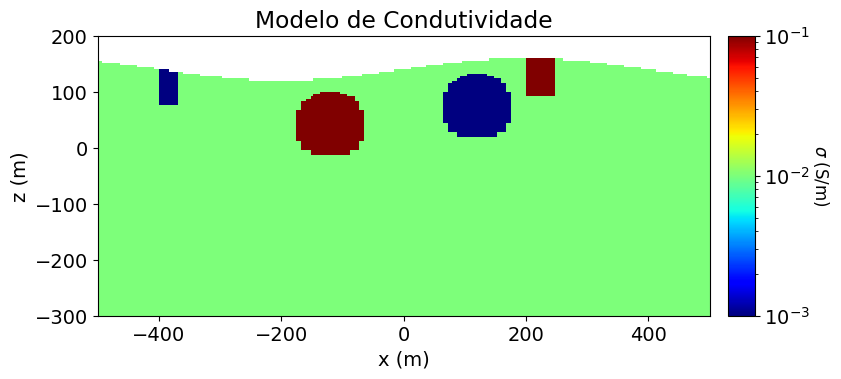

In [ ]:
conductivity_model = background_conductivity * np.ones(n_active)

###################################### DEFININDO AS ANOMALIAS ######################################


ind_conductor = model_builder.get_indices_sphere(
    np.r_[-120.0, 40.0], 60.0, mesh.cell_centers[active_cells, :])
conductivity_model[ind_conductor] = conductor_conductivity


ind_resistor = model_builder.get_indices_sphere(
    np.r_[120.0, 72.0], 60.0, mesh.cell_centers[active_cells, :])
conductivity_model[ind_resistor] = resistor_conductivity


ind_resistor = model_builder.get_indices_block(
    [-400.0, 200.0], [-370.0, 78.0], mesh.cell_centers[active_cells, :])
conductivity_model[ind_resistor] = resistor_conductivity


ind_conductor = model_builder.get_indices_block(
    [200.0, 200.0], [248.0, 95.0], mesh.cell_centers[active_cells, :])
conductivity_model[ind_conductor] = conductor_conductivity

ind_conductor = model_builder.get_indices_layer()

####################################################################################################

#Definindo o modelo de log-resistividade
log_resistivity_model = np.log(1 / conductivity_model)

# Conductivity map. Model parameters are conductivities for all active cells.
conductivity_map = maps.InjectActiveCells(mesh, active_cells, air_conductivity)

# Resistivity map. Model parameters are log-resistivities for all active cells.
log_resistivity_map = maps.InjectActiveCells(
    mesh, active_cells, 1 / air_conductivity
) * maps.ExpMap(nP=n_active)

#Mapeamento para ignorar células inativas no gráfico
plotting_map = maps.InjectActiveCells(mesh, active_cells, np.nan)

#Plot
fig = plt.figure(figsize=(9, 4))
norm = LogNorm(vmin=1e-3, vmax=1e-1)
ax1 = fig.add_axes([0.14, 0.17, 0.68, 0.7])
mesh.plot_image(
    plotting_map * conductivity_model,
    ax=ax1,
    grid=False,
    pcolor_opts={"norm": norm, "cmap": mpl.cm.jet},)
ax1.set_xlim(-500, 500)
ax1.set_ylim(-300, 200)
ax1.set_title("Modelo de Condutividade")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("z (m)")
ax2 = fig.add_axes([0.84, 0.17, 0.03, 0.7])
cbar = mpl.colorbar.ColorbarBase(ax2, norm=norm, orientation="vertical", cmap=mpl.cm.jet)
cbar.set_label(r"$\sigma$ (S/m)", rotation=270, labelpad=15, size=12)
plt.show()

## Definir a Simulação Direta.

No SimPEG, a física da simulação direta é definida criando uma instância de uma classe de simulação apropriada. Existem duas classes de simulação que podem ser usadas para simular dados de resistividade DC em 2.5D:

- [Simulation2DNodel](xref:simpeg#simpeg.electromagnetics.static.resistivity.Simulation2DNodal), define os potenciais elétricos nos nós da malha.
- [Simulation2DCellCentered](xref:simpeg#simpeg.electromagnetics.static.resistivity.Simulation2DCellCentered), define os potenciais elétricos nos centros das células..

Para dados de resistividade DC de superfície, a formulação nodal é mais adequada e será utilizada aqui. A formulação centrada na célula funciona bem para simular dados de resistividade DC em poços (borehole).

Para definir completamente a simulação direta, precisamos conectar o objeto de simulação a:

o levantamento (survey)

a malha (mesh)

o mapeamento do modelo para a malha

Isso é feito definindo cada um dos itens mencionados acima como uma propriedade do objeto de simulação. Aqui, definimos dois objetos de simulação: um em que o modelo define as condutividades do subsolo, e outro em que o modelo define as log-resistividades do subsolo.

Quando nosso modelo é usado para definir a condutividade elétrica do subsolo, o mapeamento é definido utilizando o argumento de palavra-chave ``sigmaMap`` No entanto, quando nosso modelo é usado para definir a resistividade elétrica do subsolo, o mapeamento deve ser definido utilizando o argumento de palavra-chave``rhoMap``.

In [ ]:
#Projetando eletrodos para a topografia
survey.drape_electrodes_on_topography(mesh, active_cells, option="top")

# DC simulation for a conductivity model
simulation_con = dc.simulation_2d.Simulation2DNodal(
    mesh, survey=survey, sigmaMap=conductivity_map)

# DC simulation for a log-resistivity model
simulation_res = dc.simulation_2d.Simulation2DNodal(
    mesh, survey=survey, rhoMap=log_resistivity_map)

## Predição dos dados de resistividade DC.

Uma vez que qualquer simulação no SimPEG tenha sido devidamente construída, os dados simulados para um determinado vetor de modelo podem ser calculados utilizando o método [dpred](xref:simpeg#simpeg.simulation.BaseSimulation.dpred). Observe que, apesar da diferença na forma como definimos os modelos que representam as propriedades elétricas da Terra, os dados previstos por ambas as simulações são equivalentes.

In [ ]:
dpred_con = simulation_con.dpred(conductivity_model)
dpred_res = simulation_res.dpred(log_resistivity_model)

MAX ABSOLUTE ERROR = 1.1102230246251565e-15


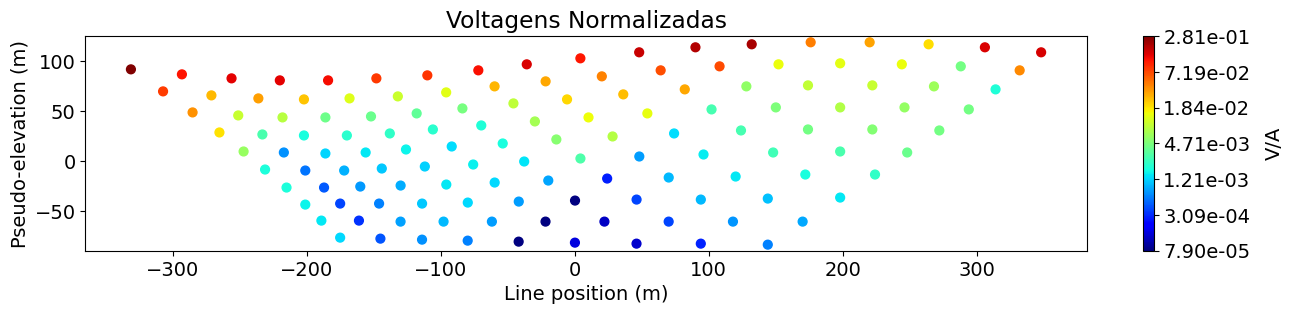

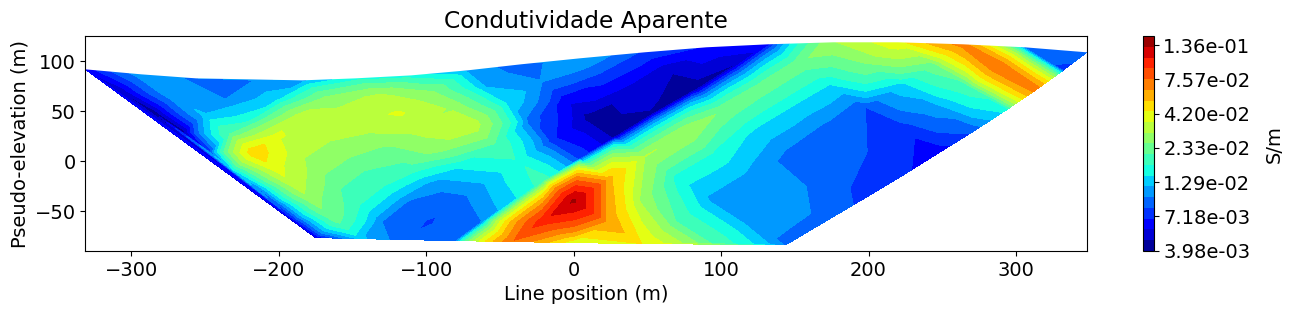

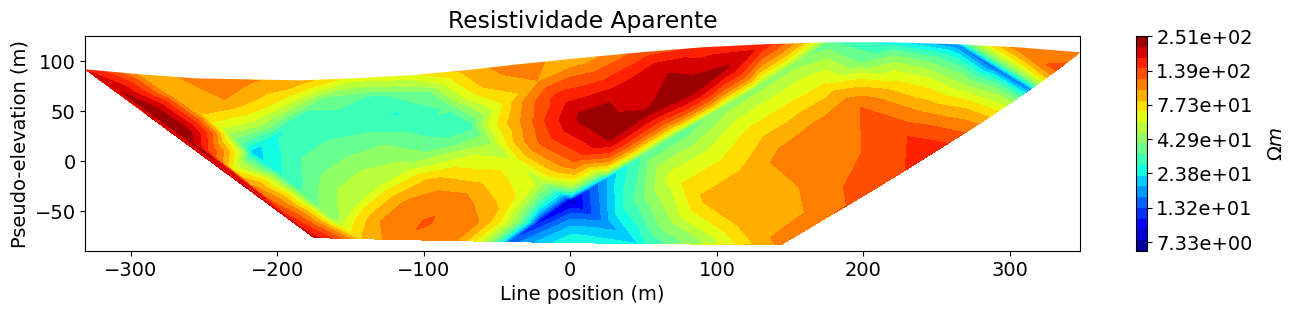

In [ ]:
#Erro
print("MAX ABSOLUTE ERROR = {}".format(np.max(np.abs(dpred_con - dpred_res))))

#Plot das voltagens normalizadas
fig = plt.figure(figsize=(15, 2.75))
ax1 = fig.add_axes([0.1, 0.15, 0.75, 0.78])
plot_pseudosection(
    survey,
    dobs=np.abs(dpred_con),
    plot_type="scatter",
    ax=ax1,
    scale="log",
    cbar_label="V/A",
    scatter_opts={"cmap": mpl.cm.jet},)
ax1.set_title("Voltagens Normalizadas")
plt.show()

#Condutividades aparentes a partir das voltagens e da geometria do levantamento
apparent_conductivities = 1 / apparent_resistivity_from_voltage(survey, dpred_con)

#Plor das condutividades aparentes
fig = plt.figure(figsize=(15, 2.75))
ax1 = fig.add_axes([0.1, 0.15, 0.75, 0.78])
plot_pseudosection(
    survey,
    dobs=apparent_conductivities,
    plot_type="contourf",
    ax=ax1,
    scale="log",
    cbar_label=r"S/m",
    mask_topography=True,
    contourf_opts={"levels": 20, "cmap": mpl.cm.jet},)
ax1.set_title("Condutividade Aparente")
plt.show()

#Plot das resistividades aparentes
fig = plt.figure(figsize=(14.9, 2.75))
ax1 = fig.add_axes([0.1, 0.15, 0.75, 0.78])
plot_pseudosection(
    survey,
    dobs=apparent_resistivity_from_voltage(survey, dpred_con),
    plot_type="contourf",
    ax=ax1,
    scale="log",
    cbar_label=r"$\Omega m$",
    mask_topography=True,
    contourf_opts={"levels": 20, "cmap": mpl.cm.jet},)
ax1.set_title("Resistividade Aparente")
plt.show()

In [ ]:
######################################## ESCREVENDO O DADO #########################################

#Acessando o Google Drive
if writeOutput:
    from google.colab import drive
    drive.mount('/content/drive')

#Escrevendo o arquivo
if writeOutput:
    dir_path = "/content/drive/My Drive/IC/data/model"
    if not os.path.exists(dir_path):
        os.makedirs(dir_path, exist_ok=True)

    #Adicionando ruído
    rng = np.random.default_rng(seed=225)
    std = 0.05 * np.abs(dpred_con)
    dc_noise = rng.normal(scale=std, size=len(dpred_con))
    dobs = dpred_con + dc_noise

    data_obj = data.Data(survey, dobs=dobs, standard_deviation=std)
    fname = os.path.join(dir_path, "modelagemslaoque.obs")
    write_dcip2d_ubc(fname, data_obj, "volt", "dobs")

    fname = dir_path + "topo.txt"
    np.savetxt(fname, topo_2d, fmt="%.4e")